### Stations

In [3]:
import requests
import pandas as pd
import time
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")

from src.config import load_config

CONFIG = load_config()

In [4]:
def fetch_next_page(first_url: str,
               params: str) -> pd.DataFrame:
    data_page = []
    next_url = first_url
    headers = {"accept": "application/json"}

    while next_url:
        try:
            r = requests.get(next_url, params=params, headers=headers, timeout=(5, 30))
            r.raise_for_status()
            print (r.url)

        except requests.exceptions.Timeout:
            print("Timeout, nouvelle tentative...")
            time.sleep(2)
            continue 

        data = r.json()
        data_page.extend(data["data"])
        next_url = data.get("next")
        params = None

        time.sleep(1)
        
    df = pd.DataFrame(data_page)
    return df

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
 
def plot_station(df: pd.DataFrame) :
    # Chargement des données
    df["date_mesure"] = pd.to_datetime(df["date_mesure"])
    df = df.sort_values("date_mesure")
    # Plot : une courbe par piézomètre (code_bss)
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for code_bss, station in df.groupby("code_bss"):
        ax.plot(station["date_mesure"], station["niveau_nappe_eau"], marker="o", markersize=3, linewidth=1, label=code_bss)
    
    ax.set_title("Variation du niveau de nappe par piézomètre")
    ax.set_xlabel("Date")
    ax.set_ylabel("Niveau de nappe (m)")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Piézomètre", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_xlim(pd.Timestamp('2016-01-01'), pd.Timestamp('2027-01-01'))

    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig("niveau_nappe_multi.png", dpi=150)
    plt.show()

### Station

In [6]:
params = {
    "size": 5000, 
    "code_bss" : ",".join(CONFIG["api"]["water"]["code_bss"])
}

df_station = fetch_next_page(CONFIG["api"]["water"]["url_station"], params)
df_station = df_station.rename(columns={"y": "longitude", "x": "latitude"})

display(df_station["nom_commune"].value_counts())
display(df_station["code_bss"].value_counts())

file = f"/home/ronanguilloueee/NappeCast/data/external/station_data.csv"
df_station.to_csv(file)

https://hubeau.eaufrance.fr/api/v1/niveaux_nappes/stations?size=5000&code_bss=10906X0039%2FC2-1


nom_commune
Millas    1
Name: count, dtype: int64

code_bss
10906X0039/C2-1    1
Name: count, dtype: int64

### Piezometre

In [8]:
frames= []

for i, (code_bss, lat, lon) in enumerate(zip(df_station["code_bss"], df_station["latitude"], df_station["longitude"])):
    print (f"----- Station: {code_bss}, latitude:{lat}-longitude:{lon}")
    
    params = {
        "size": 5000, 
        "code_bss" : code_bss
    }
    df_cache = fetch_next_page(CONFIG["api"]["water"]["url_piezometre"], params)
    frames.append(df_cache)

df_piezometre = pd.concat(frames, ignore_index=True)

file = f"/home/ronanguilloueee/NappeCast/data/external/piezometre_data.csv"
df_piezometre.to_csv(file)

----- Station: 10906X0039/C2-1, latitude:2.685378283-longitude:42.685696389
https://hubeau.eaufrance.fr/api/v1/niveaux_nappes/chroniques?size=5000&code_bss=10906X0039%2FC2-1
https://hubeau.eaufrance.fr/api/v1/niveaux_nappes/chroniques?code_bss=10906X0039/C2-1&page=2&size=5000


----- Station: 10906X0039/C2-1, latitude:2.685378283-longitude:42.685696389


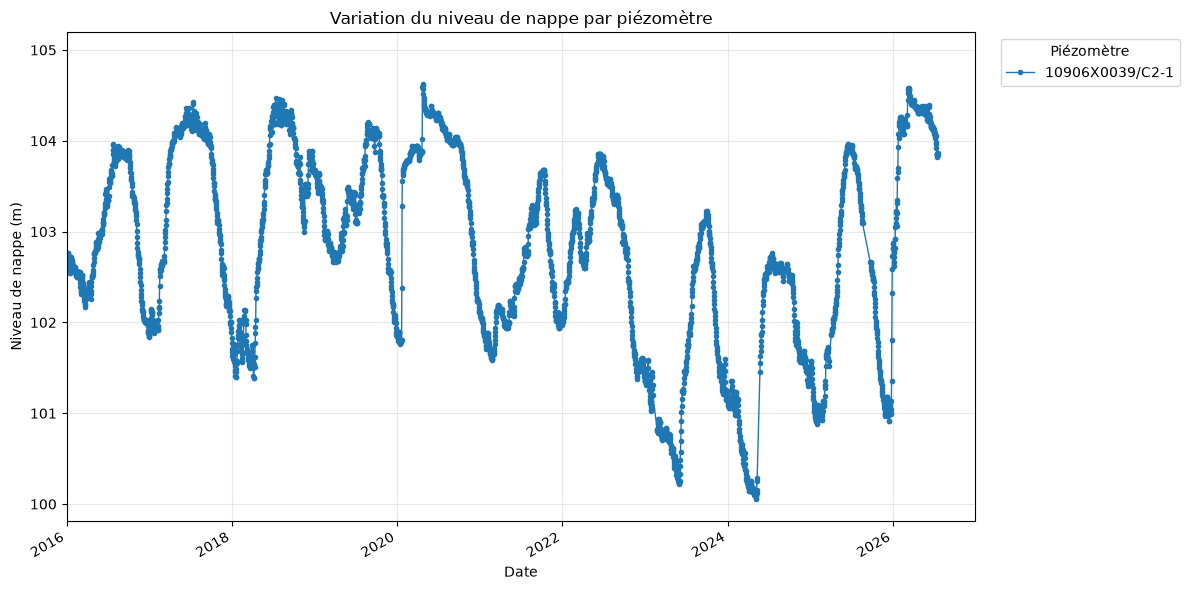

In [10]:
for i, (code_station, lat, lon) in enumerate(zip(df_station["code_bss"], df_station["latitude"], df_station["longitude"])):
    print (f"----- Station: {code_station}, latitude:{lat}-longitude:{lon}")

    mask = (df_piezometre["code_bss"]==code_station)
    df_choice = df_piezometre[mask]
    
    plot_station (df_choice)
